In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "625-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
# Loading in previous 625 nm no-IMR-offset fit from vampires_calibration
start_file = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/625-50_restrictive_HWP_FLC_no_IMR_offset_with_dichroic_best_fit_old_fit_values.txt"
with open(start_file, "r") as f:
    past_fit = json.load(f)

past_fit.setdefault("image_rotator", {}).pop("delta_theta", None)
print("Starting file: " + start_file)
print("Past Fit: ", past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"]
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"]
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"]
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.138632289044199  # calculated in em_gain_calculations/20230919_calculate_em_gain_ratios.ipynb

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)


Starting file: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/625-50_restrictive_HWP_FLC_no_IMR_offset_with_dichroic_best_fit_old_fit_values.txt
Past Fit:  {'wollaston': {'transmission_ratio': 1.113757008239718}, 'dichroic': {'phi': -0.052525473884006385, 'epsilon': 0.015242636141204524, 'theta': -0.0011119848003612303}, 'flc': {'phi': 3.3977090547141877, 'delta_theta': 1.6457931730764934}, 'optics': {'phi': -0.9770191223504372, 'epsilon': 0.09999996192811361, 'theta': 23.002471620071717}, 'image_rotator': {'phi': 1.8556533666055168}, 'hwp': {'phi': 2.7208003993624104, 'delta_theta': 3.3048056493613416}, 'lp': {'theta': 4.9999993269652805}}
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.138632289044199}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.39

In [4]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.53607289 0.52792874 0.09308807 0.        ]
 [0.53607289 0.52792874 0.09308807 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -0.052525473884006385, 'epsilon': 0.015242636141204524, 'theta': -0.0011119848003612303}, 'flc': {'phi': 3.3977090547141877, 'delta_theta': 1.6457931730764934}, 'optics': {'phi': -0.9770191223504372, 'epsilon': 0.09999996192811361, 'theta': 23.002471620071717}, 'image_rotator': {'phi': 1.8556533666055168}, 'hwp': {'phi': 2.7208003993624104, 'delta_theta': 3.3048056493613416}, 'lp': {'theta': 4.9999993269652805}}
logl value: 1109.6097626149517


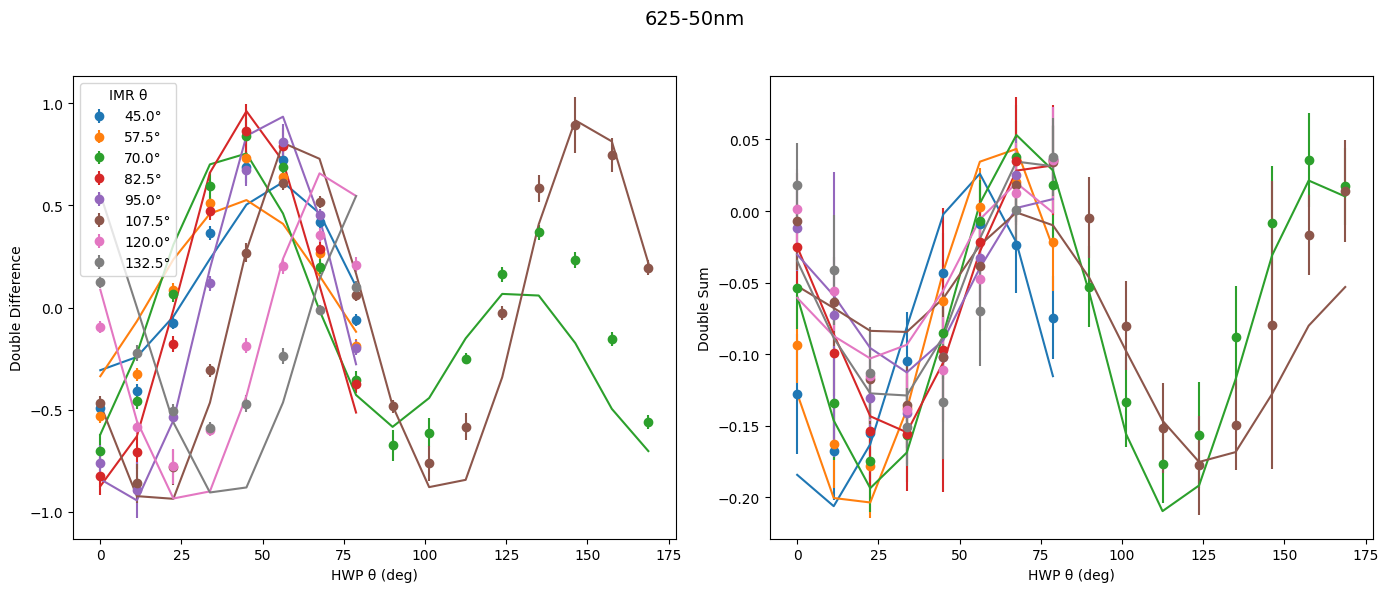

In [5]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)
p0.setdefault("image_rotator", {}).pop("delta_theta", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting initial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)


# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': -0.052525473884006385, 'epsilon': 0.015242636141204524, 'theta': -0.0011119848003612303}, 'flc': {'phi': 3.3977090547141877, 'delta_theta': 1.6457931730764934}, 'optics': {'phi': -0.9770191223504372, 'epsilon': 0.09999996192811361, 'theta': 23.002471620071717}, 'image_rotator': {'phi': 1.8556533666055168}, 'hwp': {'phi': 2.7208003993624104, 'delta_theta': 3.3048056493613416}, 'lp': {'theta': 4.9999993269652805}}
Iteration #: 1
logl_value: 464.58204970457064
Best Fit Parameters: [-1.95859516e+00  6.59014831e-03 -2.95374009e-02  3.36970570e+00
  1.84042250e+00 -8.77515632e-01  8.56348677e-02  2.14747883e+01
  1.67008807e+00  2.77448568e+00  2.29202580e+00  4.99995700e+00]


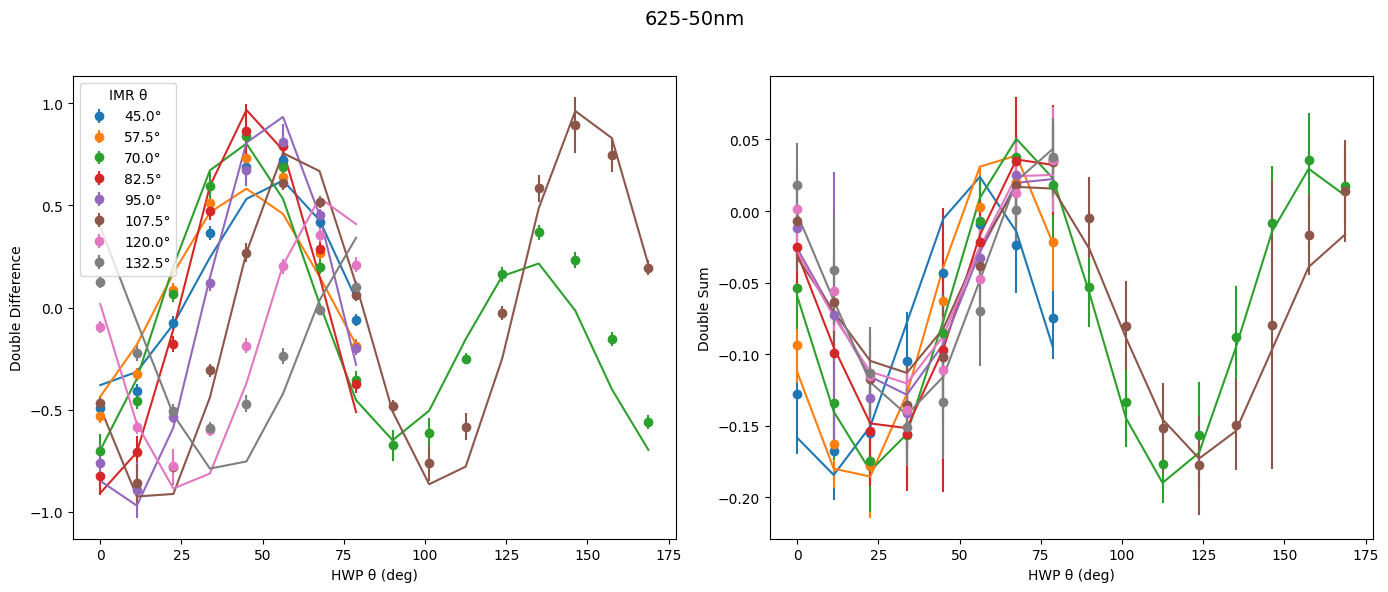

After p0: {'dichroic': {'phi': -1.958595163616995, 'epsilon': 0.006590148314868578, 'theta': -0.029537400948177816}, 'flc': {'phi': 3.369705696950657, 'delta_theta': 1.8404224970788734}, 'optics': {'phi': -0.8775156321431079, 'epsilon': 0.08563486769123353, 'theta': 21.474788258387846}, 'image_rotator': {'phi': 1.6700880662494093}, 'hwp': {'phi': 2.7744856826059077, 'delta_theta': 2.292025797488202}, 'lp': {'theta': 4.999957003960743}}
Before p0: {'dichroic': {'phi': -1.958595163616995, 'epsilon': 0.006590148314868578, 'theta': -0.029537400948177816}, 'flc': {'phi': 3.369705696950657, 'delta_theta': 1.8404224970788734}, 'optics': {'phi': -0.8775156321431079, 'epsilon': 0.08563486769123353, 'theta': 21.474788258387846}, 'image_rotator': {'phi': 1.6700880662494093}, 'hwp': {'phi': 2.7744856826059077, 'delta_theta': 2.292025797488202}, 'lp': {'theta': 4.999957003960743}}
Iteration #: 2
logl_value: 462.40158746400914
Best Fit Parameters: [-1.95325821e+00  7.11716628e-03 -5.99673808e+00  3.

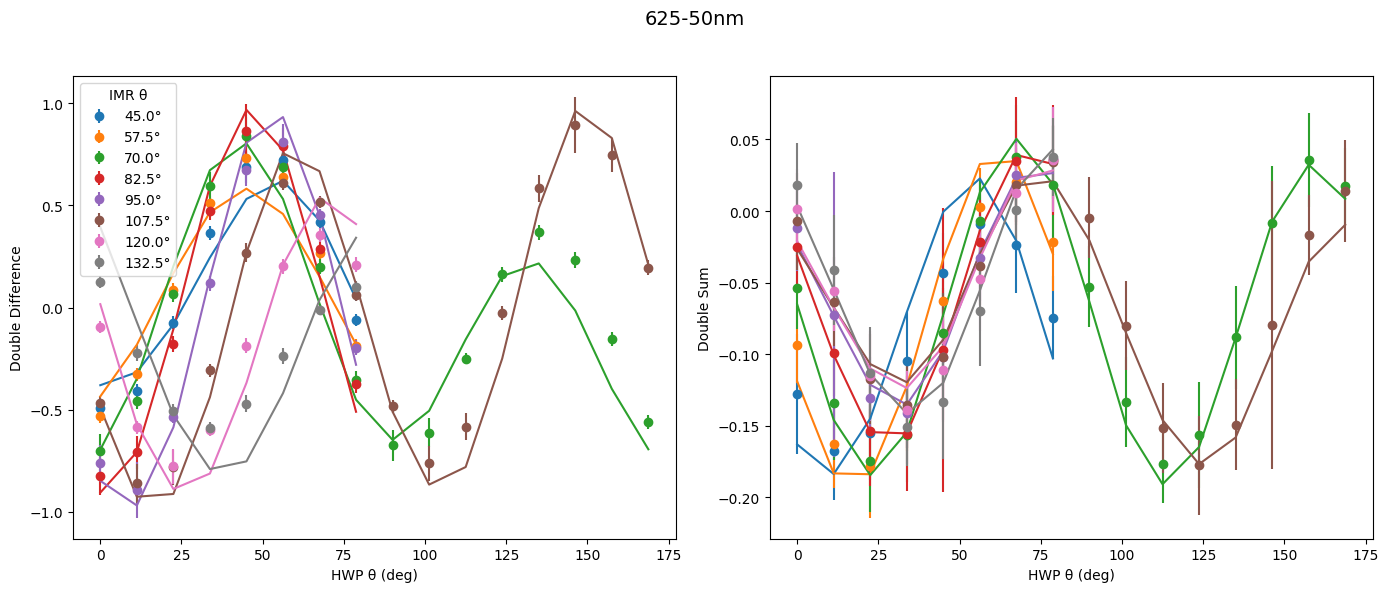

After p0: {'dichroic': {'phi': -1.9532582059390249, 'epsilon': 0.007117166276193146, 'theta': -5.99673807872534}, 'flc': {'phi': 3.0199386712908094, 'delta_theta': -2.585932683574825}, 'optics': {'phi': -0.6415391315355161, 'epsilon': 0.08432196431531253, 'theta': 20.635204151622247}, 'image_rotator': {'phi': 1.6700880619305387}, 'hwp': {'phi': 2.774951151205313, 'delta_theta': 2.27690196315819}, 'lp': {'theta': 4.957733775979097}}
Before p0: {'dichroic': {'phi': -1.9532582059390249, 'epsilon': 0.007117166276193146, 'theta': -5.99673807872534}, 'flc': {'phi': 3.0199386712908094, 'delta_theta': -2.585932683574825}, 'optics': {'phi': -0.6415391315355161, 'epsilon': 0.08432196431531253, 'theta': 20.635204151622247}, 'image_rotator': {'phi': 1.6700880619305387}, 'hwp': {'phi': 2.774951151205313, 'delta_theta': 2.27690196315819}, 'lp': {'theta': 4.957733775979097}}
Iteration #: 3
logl_value: 460.38833242043427
Best Fit Parameters: [-1.56014870e+00  8.33061761e-03 -4.21379125e+00  3.10075690

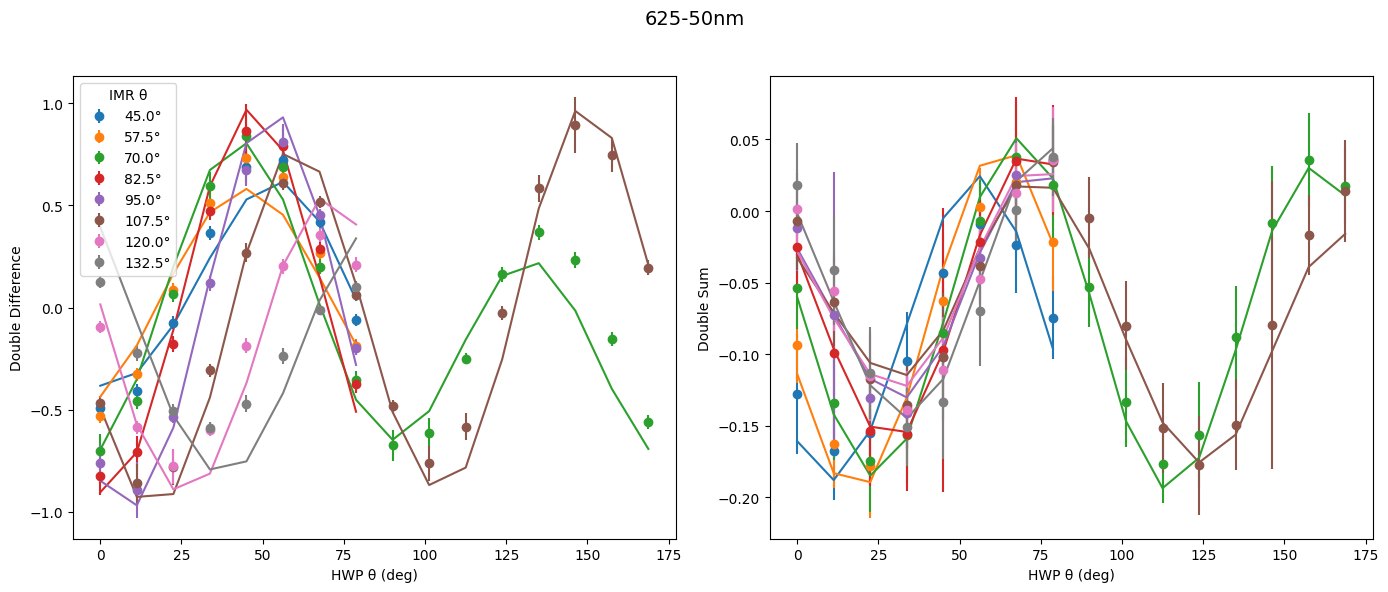

After p0: {'dichroic': {'phi': -1.5601487018018552, 'epsilon': 0.008330617612822718, 'theta': -4.213791254833693}, 'flc': {'phi': 3.1007569000225192, 'delta_theta': -0.794403006766806}, 'optics': {'phi': -0.7755353656699511, 'epsilon': 0.08373703198618355, 'theta': 18.339177654261448}, 'image_rotator': {'phi': 1.6700880413774069}, 'hwp': {'phi': 2.776461061788034, 'delta_theta': 2.294251336060754}, 'lp': {'theta': 4.998858022994696}}
Before p0: {'dichroic': {'phi': -1.5601487018018552, 'epsilon': 0.008330617612822718, 'theta': -4.213791254833693}, 'flc': {'phi': 3.1007569000225192, 'delta_theta': -0.794403006766806}, 'optics': {'phi': -0.7755353656699511, 'epsilon': 0.08373703198618355, 'theta': 18.339177654261448}, 'image_rotator': {'phi': 1.6700880413774069}, 'hwp': {'phi': 2.776461061788034, 'delta_theta': 2.294251336060754}, 'lp': {'theta': 4.998858022994696}}
Iteration #: 4
logl_value: 460.30997797115725
Best Fit Parameters: [-8.83354425e-01  8.05366909e-03 -6.11565300e+00  3.0672

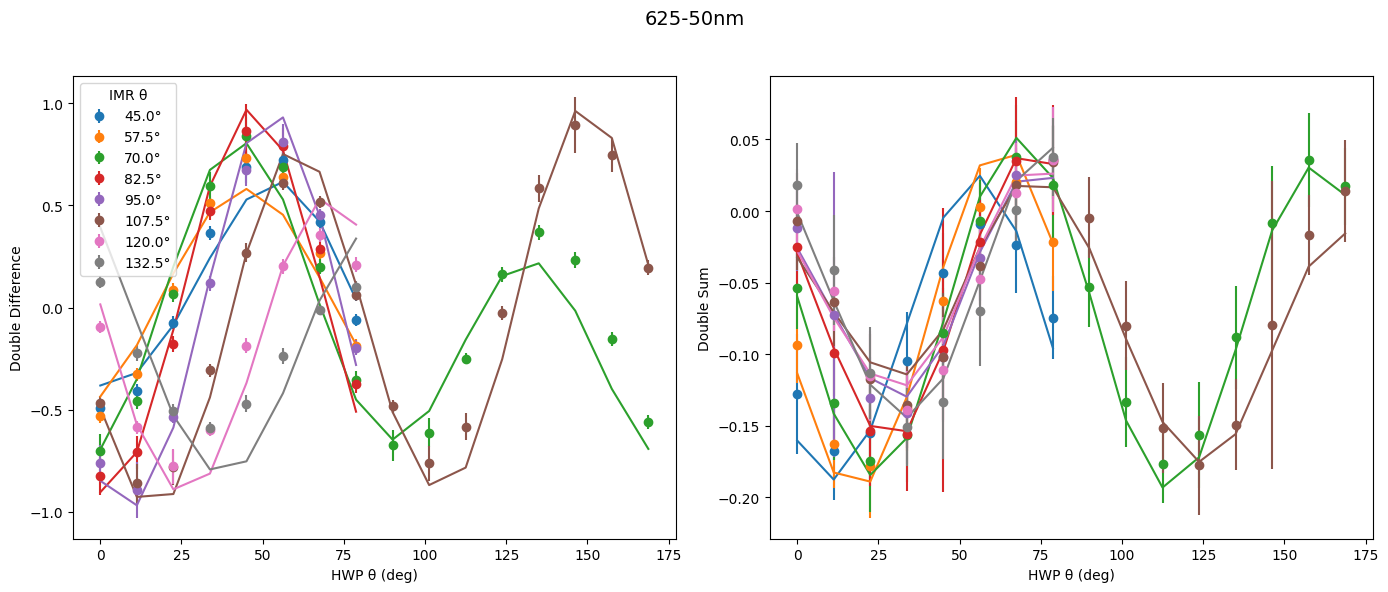

After p0: {'dichroic': {'phi': -0.8833544246604805, 'epsilon': 0.008053669089253618, 'theta': -6.1156530038288714}, 'flc': {'phi': 3.067210838076475, 'delta_theta': 0.1593830315366051}, 'optics': {'phi': -0.7455701332566615, 'epsilon': 0.08339326765100147, 'theta': 18.289174005736527}, 'image_rotator': {'phi': 1.67008808813071}, 'hwp': {'phi': 2.775944624983783, 'delta_theta': 2.2831674066650702}, 'lp': {'theta': 4.999951932667361}}
Before p0: {'dichroic': {'phi': -0.8833544246604805, 'epsilon': 0.008053669089253618, 'theta': -6.1156530038288714}, 'flc': {'phi': 3.067210838076475, 'delta_theta': 0.1593830315366051}, 'optics': {'phi': -0.7455701332566615, 'epsilon': 0.08339326765100147, 'theta': 18.289174005736527}, 'image_rotator': {'phi': 1.67008808813071}, 'hwp': {'phi': 2.775944624983783, 'delta_theta': 2.2831674066650702}, 'lp': {'theta': 4.999951932667361}}
Iteration #: 5
logl_value: 460.2634466829384
Best Fit Parameters: [-5.48004555e-01  8.49301845e-03 -8.99577973e+00  3.0717887

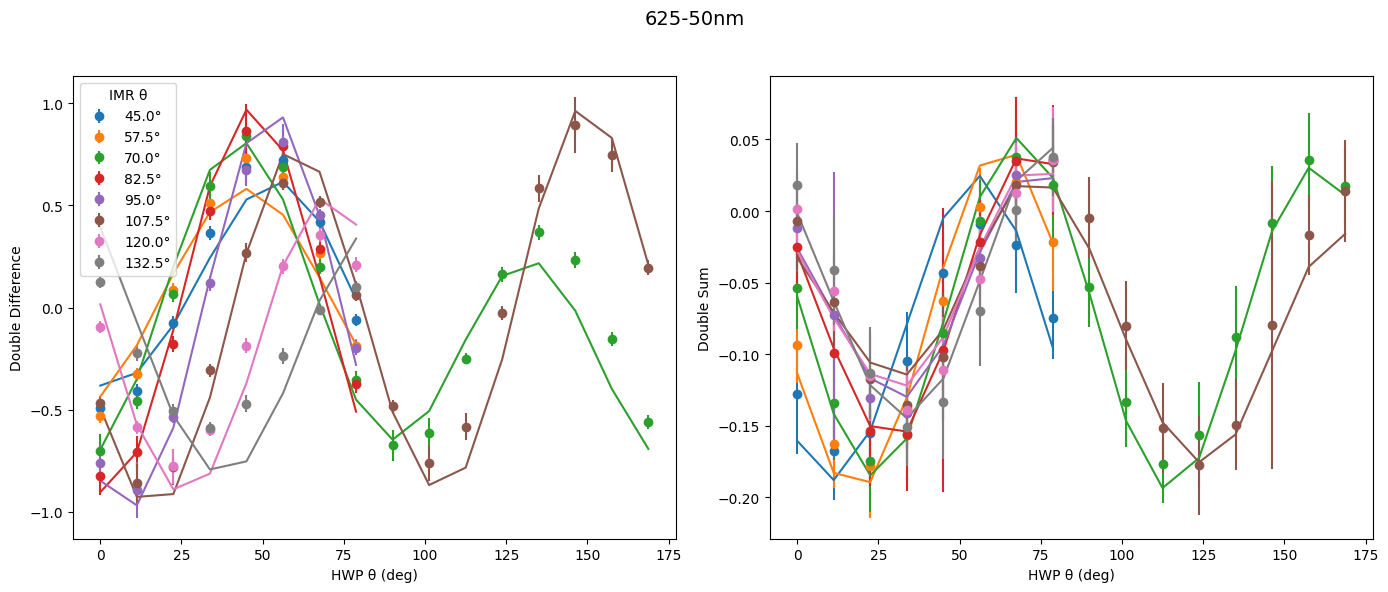

After p0: {'dichroic': {'phi': -0.5480045545039798, 'epsilon': 0.008493018446780982, 'theta': -8.99577972681396}, 'flc': {'phi': 3.071788793288114, 'delta_theta': 0.6190447081889632}, 'optics': {'phi': -0.7513170955464166, 'epsilon': 0.08336850593435215, 'theta': 18.216446217272075}, 'image_rotator': {'phi': 1.6700886388663287}, 'hwp': {'phi': 2.7759185345687465, 'delta_theta': 2.2820850741293848}, 'lp': {'theta': 4.996945455683405}}
Before p0: {'dichroic': {'phi': -0.5480045545039798, 'epsilon': 0.008493018446780982, 'theta': -8.99577972681396}, 'flc': {'phi': 3.071788793288114, 'delta_theta': 0.6190447081889632}, 'optics': {'phi': -0.7513170955464166, 'epsilon': 0.08336850593435215, 'theta': 18.216446217272075}, 'image_rotator': {'phi': 1.6700886388663287}, 'hwp': {'phi': 2.7759185345687465, 'delta_theta': 2.2820850741293848}, 'lp': {'theta': 4.996945455683405}}
Iteration #: 6
logl_value: 460.2486012238073
Best Fit Parameters: [-4.62531888e-01  8.62343130e-03 -1.04166680e+01  3.07578

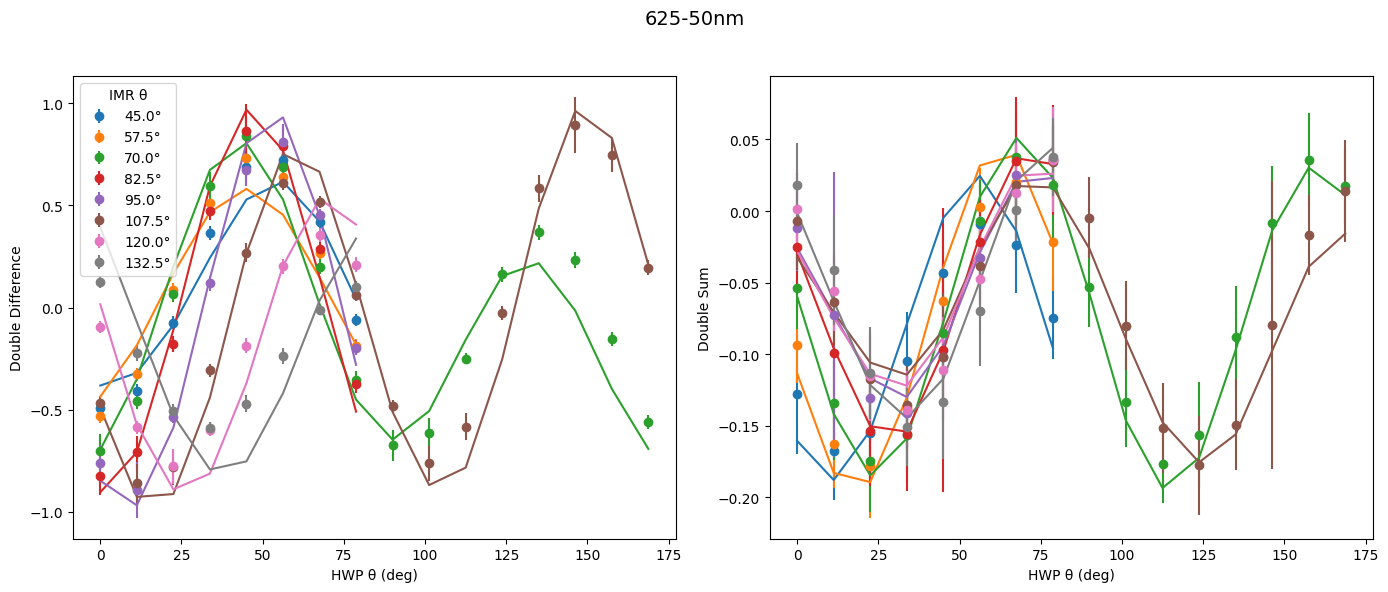

After p0: {'dichroic': {'phi': -0.4625318877634389, 'epsilon': 0.008623431296024026, 'theta': -10.416668021992535}, 'flc': {'phi': 3.0757821429138072, 'delta_theta': 0.7440842542093883}, 'optics': {'phi': -0.7541241932929654, 'epsilon': 0.08330482204401207, 'theta': 18.23147031090245}, 'image_rotator': {'phi': 1.6700912541847988}, 'hwp': {'phi': 2.775964075256965, 'delta_theta': 2.2809710212364407}, 'lp': {'theta': 4.9994193788652055}}
Before p0: {'dichroic': {'phi': -0.4625318877634389, 'epsilon': 0.008623431296024026, 'theta': -10.416668021992535}, 'flc': {'phi': 3.0757821429138072, 'delta_theta': 0.7440842542093883}, 'optics': {'phi': -0.7541241932929654, 'epsilon': 0.08330482204401207, 'theta': 18.23147031090245}, 'image_rotator': {'phi': 1.6700912541847988}, 'hwp': {'phi': 2.775964075256965, 'delta_theta': 2.2809710212364407}, 'lp': {'theta': 4.9994193788652055}}
Iteration #: 7
logl_value: 460.2122518308131
Best Fit Parameters: [-3.09624100e-01  9.61667889e-03 -1.61250033e+01  3.0

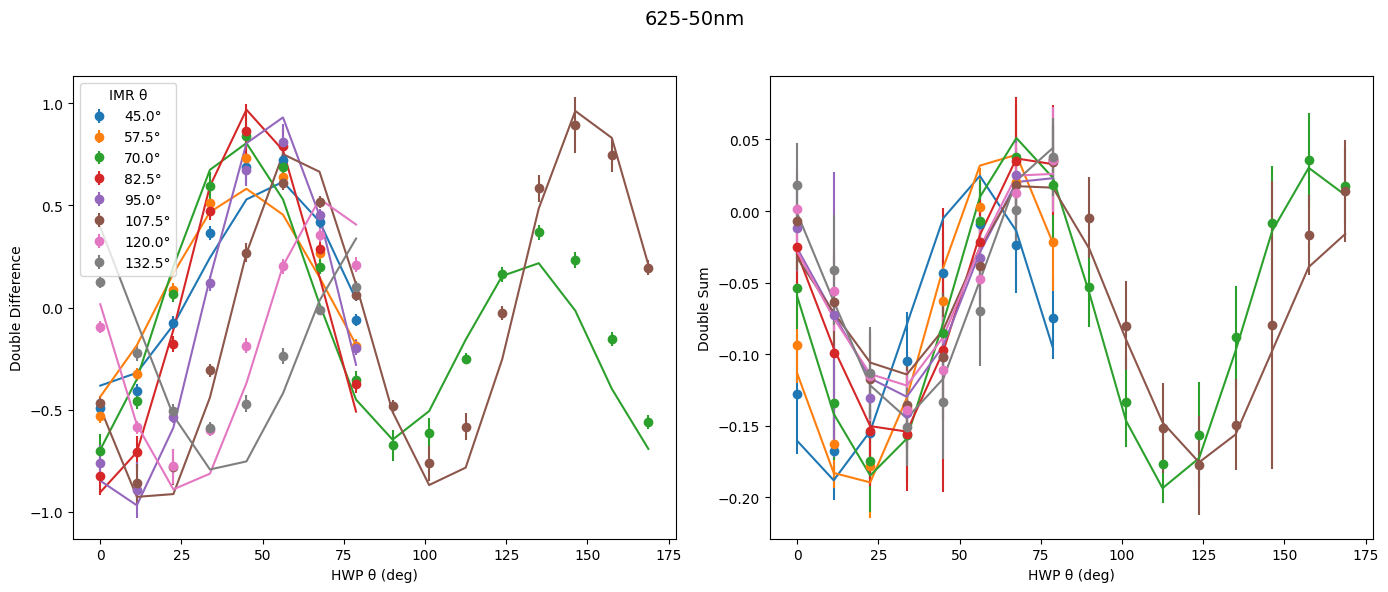

After p0: {'dichroic': {'phi': -0.3096241004947986, 'epsilon': 0.009616678893083395, 'theta': -16.125003325144036}, 'flc': {'phi': 3.0679845071640326, 'delta_theta': 0.9177996908189874}, 'optics': {'phi': -0.74861603195012, 'epsilon': 0.08316274667455664, 'theta': 18.185480092172753}, 'image_rotator': {'phi': 1.6700954534873578}, 'hwp': {'phi': 2.775780833575757, 'delta_theta': 2.2837078433779947}, 'lp': {'theta': 4.999561297568096}}
Before p0: {'dichroic': {'phi': -0.3096241004947986, 'epsilon': 0.009616678893083395, 'theta': -16.125003325144036}, 'flc': {'phi': 3.0679845071640326, 'delta_theta': 0.9177996908189874}, 'optics': {'phi': -0.74861603195012, 'epsilon': 0.08316274667455664, 'theta': 18.185480092172753}, 'image_rotator': {'phi': 1.6700954534873578}, 'hwp': {'phi': 2.775780833575757, 'delta_theta': 2.2837078433779947}, 'lp': {'theta': 4.999561297568096}}
Iteration #: 8
logl_value: 459.8391172729671
Best Fit Parameters: [-1.77082600e-01  3.19024455e-02 -3.84828384e+01  3.04966

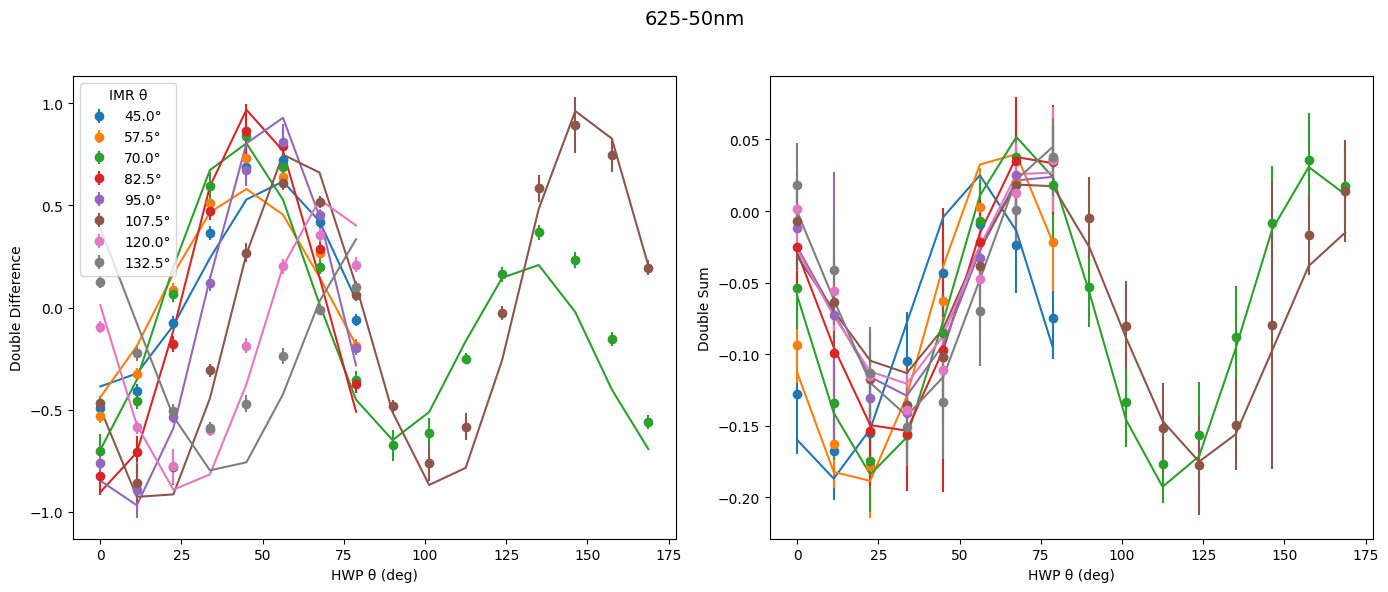

After p0: {'dichroic': {'phi': -0.17708259956109607, 'epsilon': 0.031902445481089364, 'theta': -38.482838400289126}, 'flc': {'phi': 3.049669034818355, 'delta_theta': 1.1755450685662387}, 'optics': {'phi': -0.7279390655591778, 'epsilon': 0.08742884997971011, 'theta': 18.352418667785543}, 'image_rotator': {'phi': 1.6700974715351116}, 'hwp': {'phi': 2.771911458203663, 'delta_theta': 2.2550031977149088}, 'lp': {'theta': 4.928697482103526}}
Before p0: {'dichroic': {'phi': -0.17708259956109607, 'epsilon': 0.031902445481089364, 'theta': -38.482838400289126}, 'flc': {'phi': 3.049669034818355, 'delta_theta': 1.1755450685662387}, 'optics': {'phi': -0.7279390655591778, 'epsilon': 0.08742884997971011, 'theta': 18.352418667785543}, 'image_rotator': {'phi': 1.6700974715351116}, 'hwp': {'phi': 2.771911458203663, 'delta_theta': 2.2550031977149088}, 'lp': {'theta': 4.928697482103526}}
Iteration #: 9
logl_value: 331.4785206719014
Best Fit Parameters: [ -0.21993292   0.55670095 -44.66369216   3.00148477 

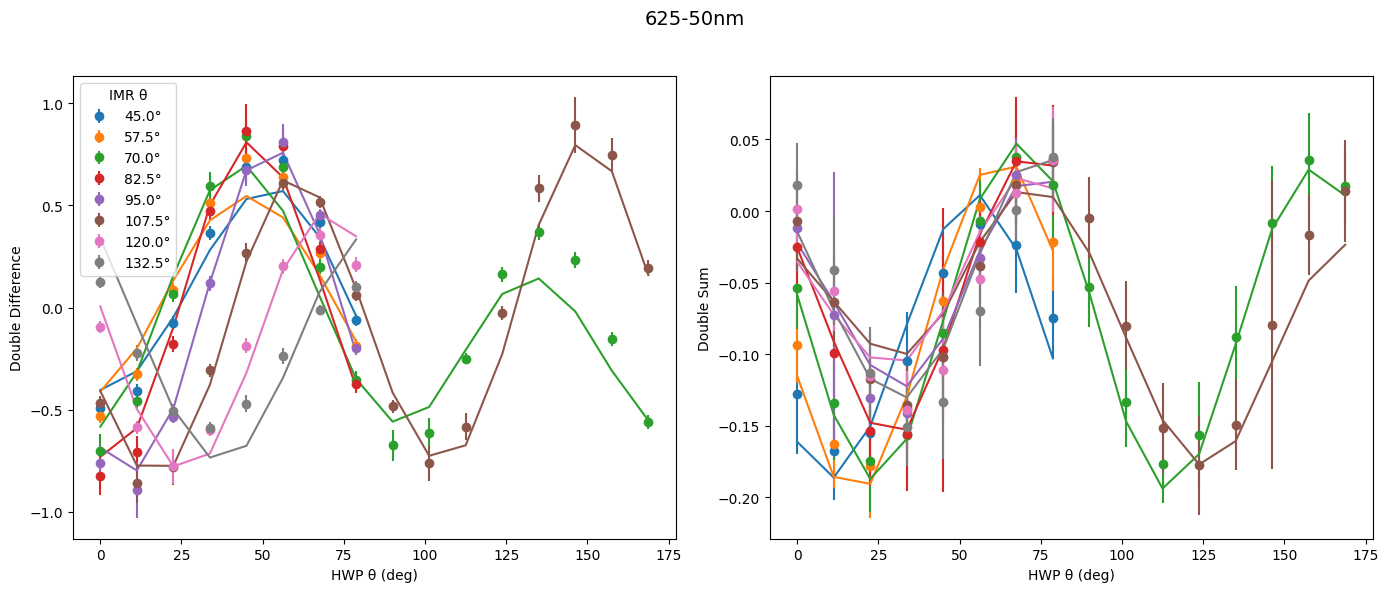

After p0: {'dichroic': {'phi': -0.21993291804220436, 'epsilon': 0.5567009488864632, 'theta': -44.6636921595133}, 'flc': {'phi': 3.001484769299923, 'delta_theta': 0.4367387118161732}, 'optics': {'phi': -0.7522018799240657, 'epsilon': 0.09315177782346701, 'theta': 21.173425313089638}, 'image_rotator': {'phi': 1.6701201723639068}, 'hwp': {'phi': 2.722673965480295, 'delta_theta': 3.347708301001618}, 'lp': {'theta': 4.8044640699016625}}
Before p0: {'dichroic': {'phi': -0.21993291804220436, 'epsilon': 0.5567009488864632, 'theta': -44.6636921595133}, 'flc': {'phi': 3.001484769299923, 'delta_theta': 0.4367387118161732}, 'optics': {'phi': -0.7522018799240657, 'epsilon': 0.09315177782346701, 'theta': 21.173425313089638}, 'image_rotator': {'phi': 1.6701201723639068}, 'hwp': {'phi': 2.722673965480295, 'delta_theta': 3.347708301001618}, 'lp': {'theta': 4.8044640699016625}}
Iteration #: 10
logl_value: 329.47958665808295
Best Fit Parameters: [ -0.2210714    0.57067658 -44.68488355   2.99407788   0.64

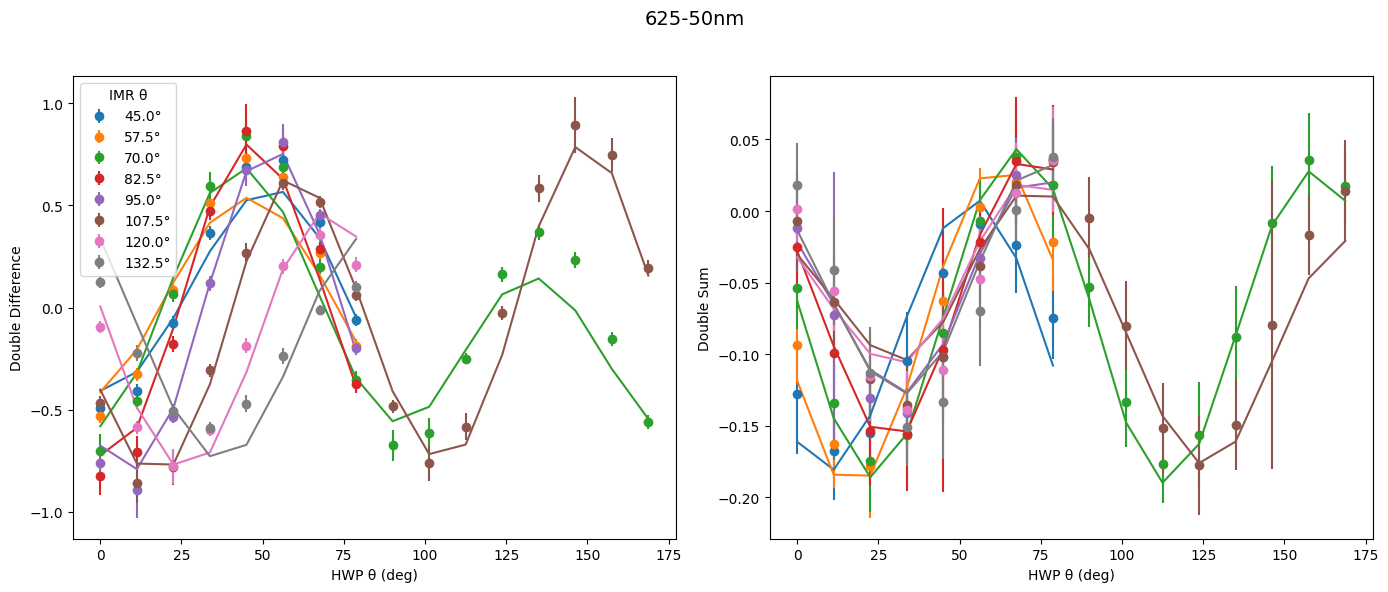

After p0: {'dichroic': {'phi': -0.22107139774904289, 'epsilon': 0.5706765844246674, 'theta': -44.6848835457821}, 'flc': {'phi': 2.9940778792459515, 'delta_theta': 0.6442990929281298}, 'optics': {'phi': -0.7128437736076412, 'epsilon': 0.09778644114465529, 'theta': 22.78602042169434}, 'image_rotator': {'phi': 1.6700885362968405}, 'hwp': {'phi': 2.727072556753029, 'delta_theta': 3.504552016866512}, 'lp': {'theta': 4.998943706716487}}
Before p0: {'dichroic': {'phi': -0.22107139774904289, 'epsilon': 0.5706765844246674, 'theta': -44.6848835457821}, 'flc': {'phi': 2.9940778792459515, 'delta_theta': 0.6442990929281298}, 'optics': {'phi': -0.7128437736076412, 'epsilon': 0.09778644114465529, 'theta': 22.78602042169434}, 'image_rotator': {'phi': 1.6700885362968405}, 'hwp': {'phi': 2.727072556753029, 'delta_theta': 3.504552016866512}, 'lp': {'theta': 4.998943706716487}}
Iteration #: 11
logl_value: 329.4656892552274
Best Fit Parameters: [ -0.21866705   0.56954054 -44.68657361   2.99828805   0.64678

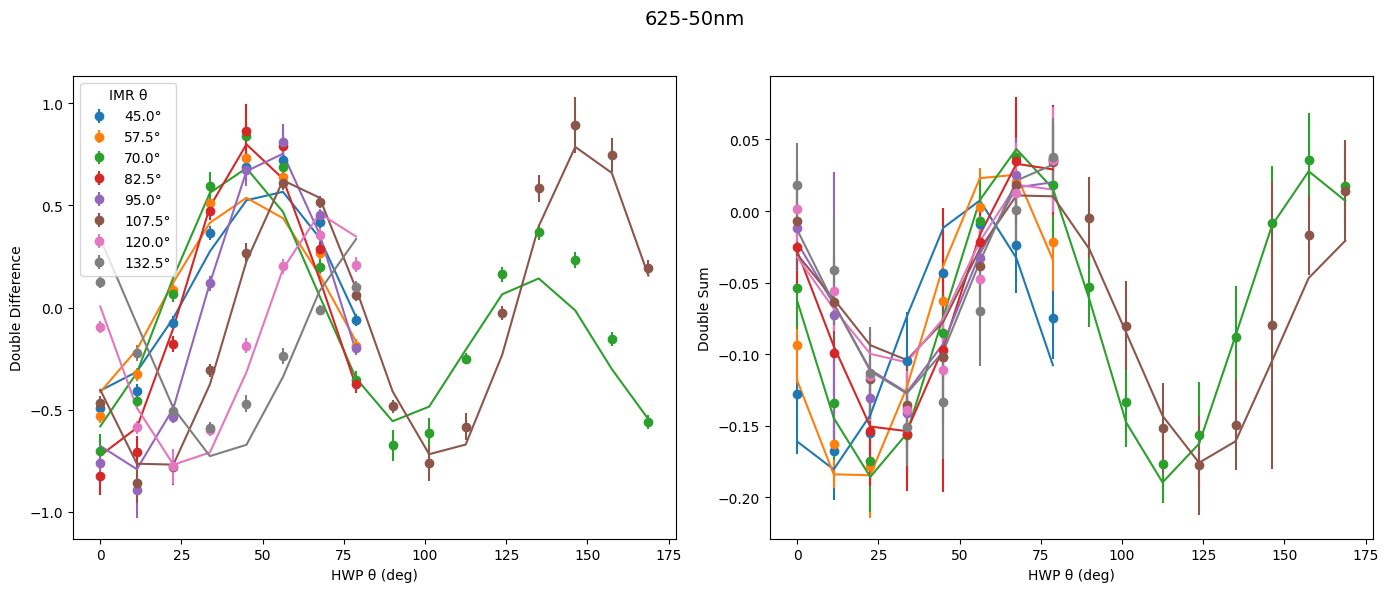

After p0: {'dichroic': {'phi': -0.21866705085539379, 'epsilon': 0.5695405366324863, 'theta': -44.68657361056417}, 'flc': {'phi': 2.998288050605297, 'delta_theta': 0.6467893841375891}, 'optics': {'phi': -0.7161917188556695, 'epsilon': 0.09758778710595298, 'theta': 22.695403809512136}, 'image_rotator': {'phi': 1.6700880304066121}, 'hwp': {'phi': 2.727359873319463, 'delta_theta': 3.4912612195275092}, 'lp': {'theta': 4.999974306089907}}
Before p0: {'dichroic': {'phi': -0.21866705085539379, 'epsilon': 0.5695405366324863, 'theta': -44.68657361056417}, 'flc': {'phi': 2.998288050605297, 'delta_theta': 0.6467893841375891}, 'optics': {'phi': -0.7161917188556695, 'epsilon': 0.09758778710595298, 'theta': 22.695403809512136}, 'image_rotator': {'phi': 1.6700880304066121}, 'hwp': {'phi': 2.727359873319463, 'delta_theta': 3.4912612195275092}, 'lp': {'theta': 4.999974306089907}}
Iteration #: 12
logl_value: 329.46558433238107
Best Fit Parameters: [ -0.21867797   0.56953086 -44.686681     2.99825314   0.

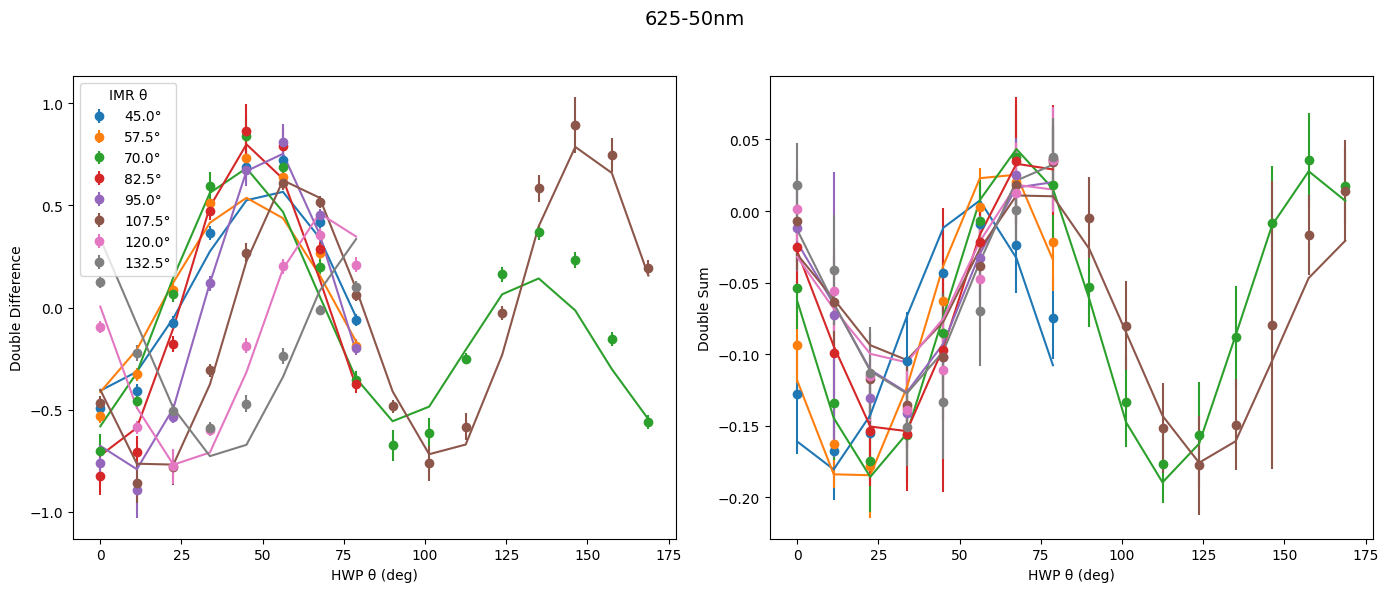

After p0: {'dichroic': {'phi': -0.2186779714270264, 'epsilon': 0.5695308594199393, 'theta': -44.68668100210513}, 'flc': {'phi': 2.998253140287728, 'delta_theta': 0.647556119645265}, 'optics': {'phi': -0.7160805941451126, 'epsilon': 0.0975910672063314, 'theta': 22.698479515082283}, 'image_rotator': {'phi': 1.6700880303941763}, 'hwp': {'phi': 2.7273703712332797, 'delta_theta': 3.4910656051991173}, 'lp': {'theta': 4.9999999911080355}}
Before p0: {'dichroic': {'phi': -0.2186779714270264, 'epsilon': 0.5695308594199393, 'theta': -44.68668100210513}, 'flc': {'phi': 2.998253140287728, 'delta_theta': 0.647556119645265}, 'optics': {'phi': -0.7160805941451126, 'epsilon': 0.0975910672063314, 'theta': 22.698479515082283}, 'image_rotator': {'phi': 1.6700880303941763}, 'hwp': {'phi': 2.7273703712332797, 'delta_theta': 3.4910656051991173}, 'lp': {'theta': 4.9999999911080355}}
Iteration #: 13
logl_value: 329.4655842259758
Best Fit Parameters: [ -0.21867225   0.56953294 -44.68669742   2.99826273   0.647

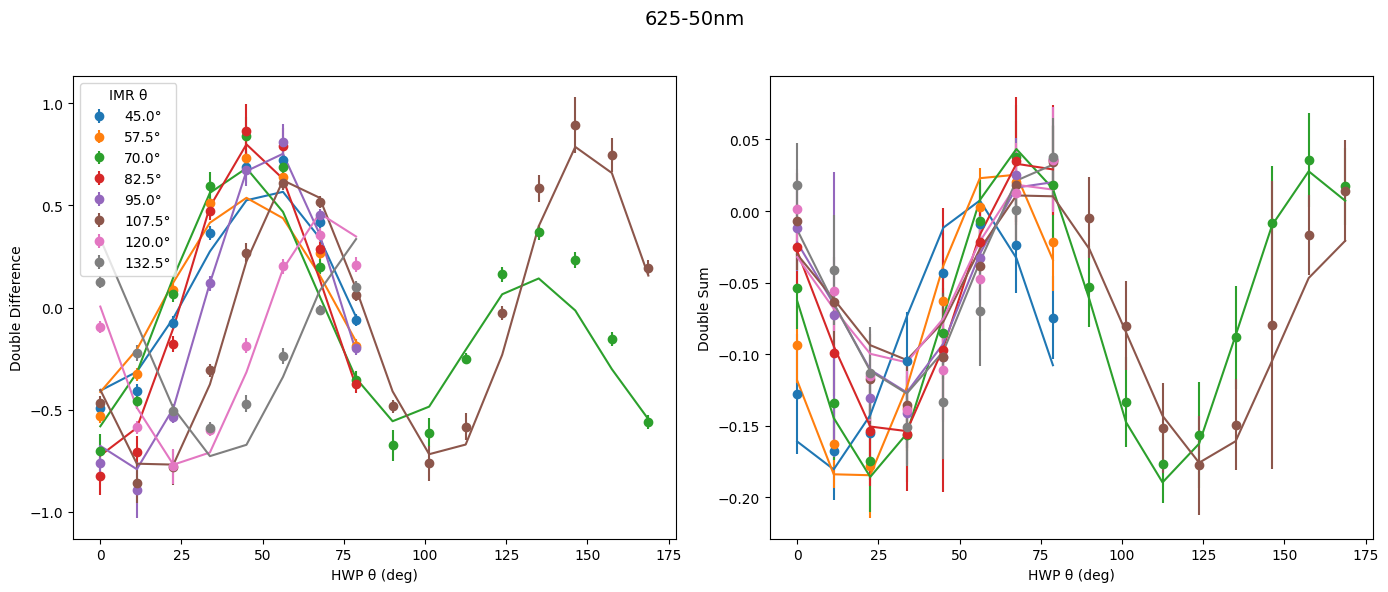

After p0: {'dichroic': {'phi': -0.21867224789280176, 'epsilon': 0.5695329384020299, 'theta': -44.68669742188455}, 'flc': {'phi': 2.9982627303862843, 'delta_theta': 0.6475511461617595}, 'optics': {'phi': -0.7160855101888225, 'epsilon': 0.09759101248504837, 'theta': 22.69837744364689}, 'image_rotator': {'phi': 1.670088030394148}, 'hwp': {'phi': 2.7273695318908393, 'delta_theta': 3.491019546467304}, 'lp': {'theta': 4.99999999297689}}
Before p0: {'dichroic': {'phi': -0.21867224789280176, 'epsilon': 0.5695329384020299, 'theta': -44.68669742188455}, 'flc': {'phi': 2.9982627303862843, 'delta_theta': 0.6475511461617595}, 'optics': {'phi': -0.7160855101888225, 'epsilon': 0.09759101248504837, 'theta': 22.69837744364689}, 'image_rotator': {'phi': 1.670088030394148}, 'hwp': {'phi': 2.7273695318908393, 'delta_theta': 3.491019546467304}, 'lp': {'theta': 4.99999999297689}}
Iteration #: 14
logl_value: 329.4655842240022
Best Fit Parameters: [ -0.21867108   0.56953368 -44.68671089   2.99826373   0.64754

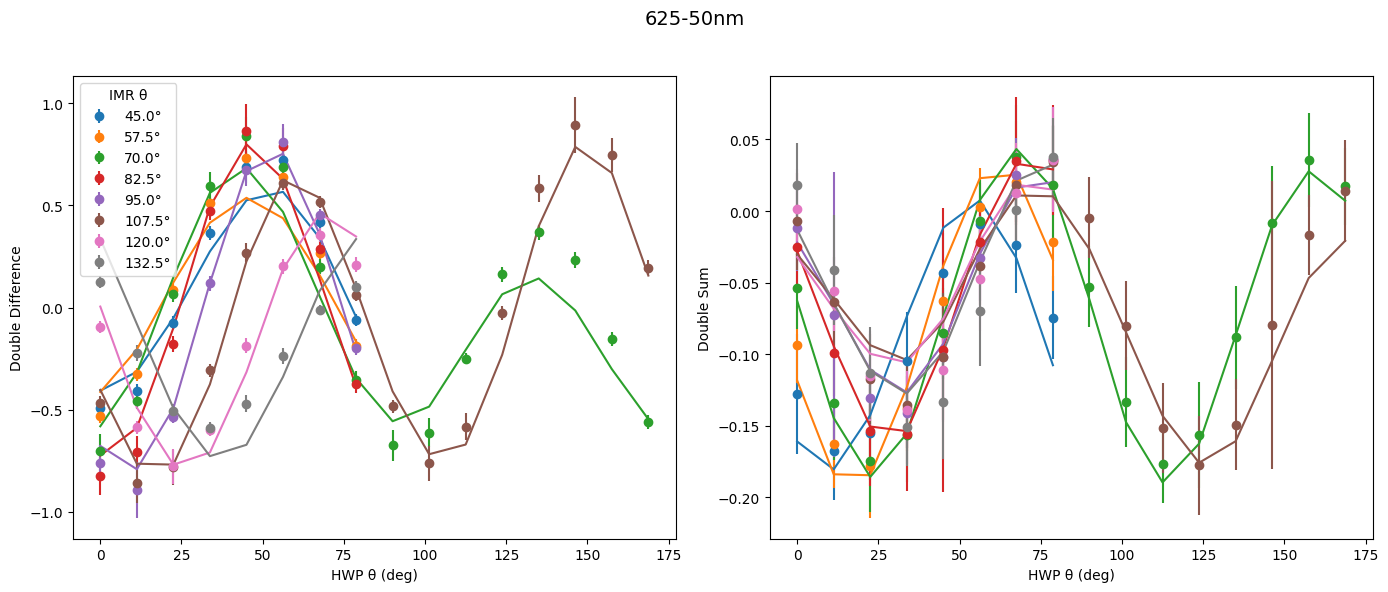

After p0: {'dichroic': {'phi': -0.21867108350294628, 'epsilon': 0.569533676831321, 'theta': -44.68671088745238}, 'flc': {'phi': 2.998263727707323, 'delta_theta': 0.6475427047675825}, 'optics': {'phi': -0.7160879995684537, 'epsilon': 0.09759164390506501, 'theta': 22.698288682154136}, 'image_rotator': {'phi': 1.6700880303942154}, 'hwp': {'phi': 2.727369954468723, 'delta_theta': 3.491015703234262}, 'lp': {'theta': 4.99999999378781}}
Before p0: {'dichroic': {'phi': -0.21867108350294628, 'epsilon': 0.569533676831321, 'theta': -44.68671088745238}, 'flc': {'phi': 2.998263727707323, 'delta_theta': 0.6475427047675825}, 'optics': {'phi': -0.7160879995684537, 'epsilon': 0.09759164390506501, 'theta': 22.698288682154136}, 'image_rotator': {'phi': 1.6700880303942154}, 'hwp': {'phi': 2.727369954468723, 'delta_theta': 3.491015703234262}, 'lp': {'theta': 4.99999999378781}}
Iteration #: 15
logl_value: 329.46558419490344
Best Fit Parameters: [ -0.21867293   0.56953282 -44.68672164   2.99826173   0.647560

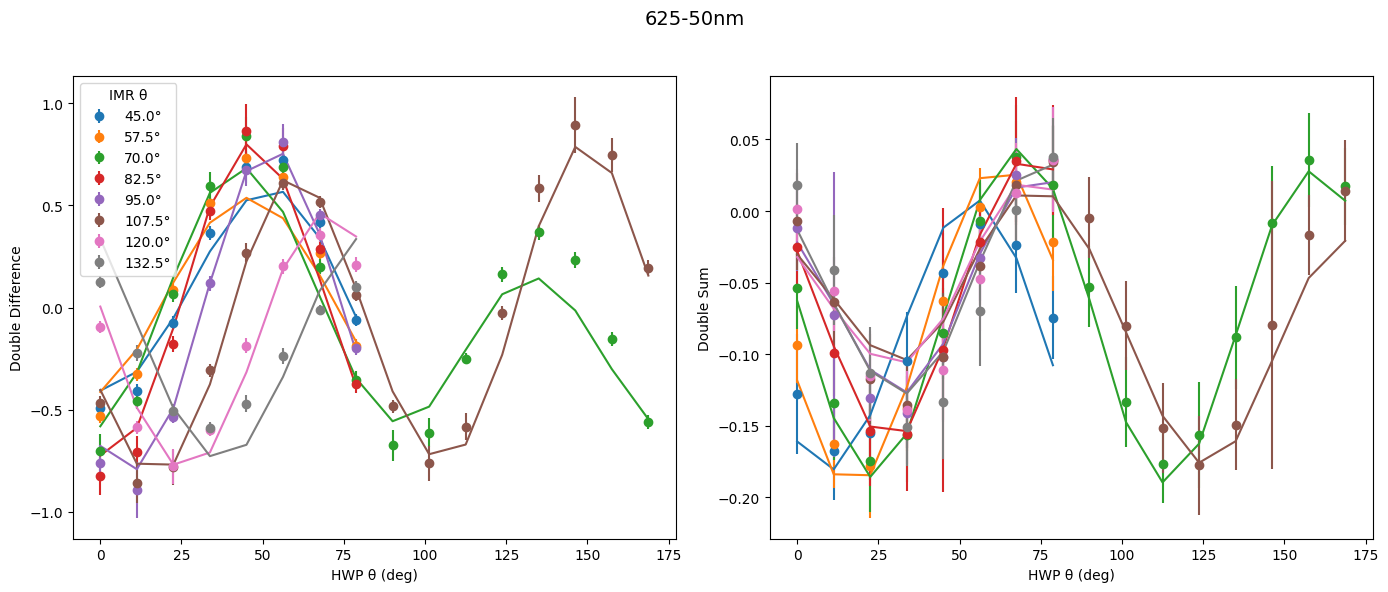

After p0: {'dichroic': {'phi': -0.21867292822509393, 'epsilon': 0.5695328161242275, 'theta': -44.686721640648514}, 'flc': {'phi': 2.998261733738783, 'delta_theta': 0.6475604127979151}, 'optics': {'phi': -0.7160821490791687, 'epsilon': 0.0975918680373217, 'theta': 22.698434406850758}, 'image_rotator': {'phi': 1.6700880303940981}, 'hwp': {'phi': 2.7273695439187984, 'delta_theta': 3.491025751900838}, 'lp': {'theta': 4.999999998310677}}
Before p0: {'dichroic': {'phi': -0.21867292822509393, 'epsilon': 0.5695328161242275, 'theta': -44.686721640648514}, 'flc': {'phi': 2.998261733738783, 'delta_theta': 0.6475604127979151}, 'optics': {'phi': -0.7160821490791687, 'epsilon': 0.0975918680373217, 'theta': 22.698434406850758}, 'image_rotator': {'phi': 1.6700880303940981}, 'hwp': {'phi': 2.7273695439187984, 'delta_theta': 3.491025751900838}, 'lp': {'theta': 4.999999998310677}}
Iteration #: 16
logl_value: 329.46558418968004
Best Fit Parameters: [ -0.21867159   0.56953181 -44.68671395   2.99826423   0.

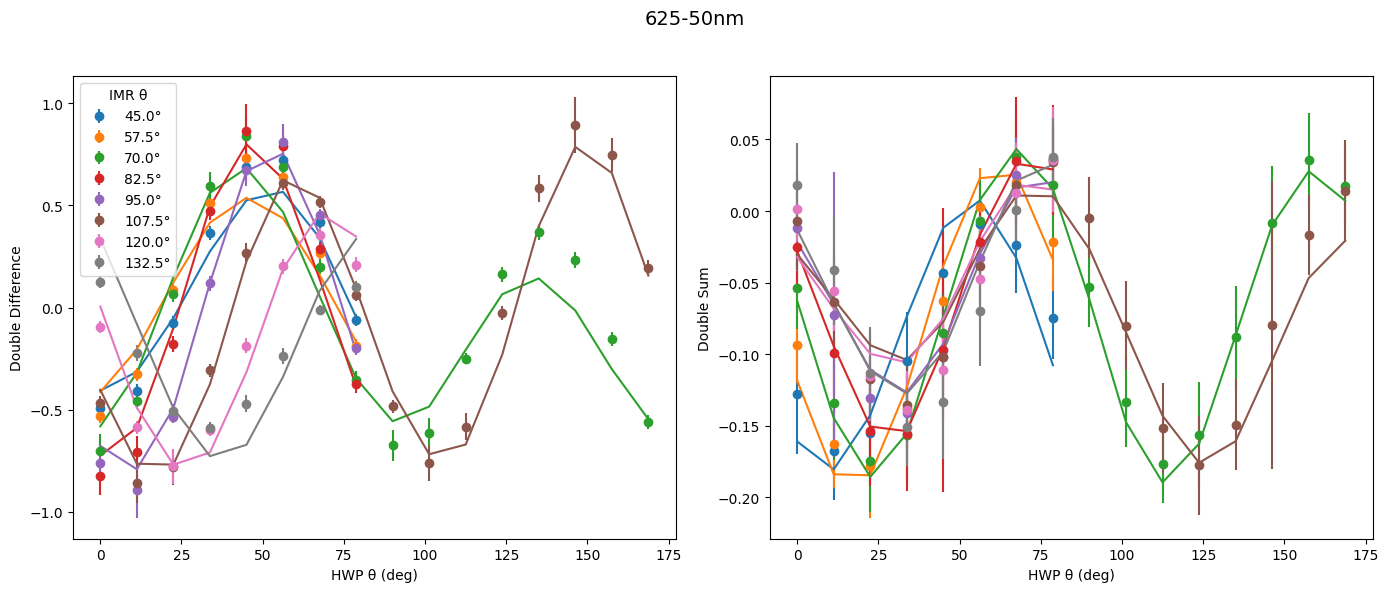

After p0: {'dichroic': {'phi': -0.2186715881073062, 'epsilon': 0.5695318115539633, 'theta': -44.68671394732425}, 'flc': {'phi': 2.998264228283791, 'delta_theta': 0.6475533686331238}, 'optics': {'phi': -0.7160851765496037, 'epsilon': 0.09759130932863187, 'theta': 22.698338494879664}, 'image_rotator': {'phi': 1.6700880303942371}, 'hwp': {'phi': 2.7273686250269105, 'delta_theta': 3.4910148607098153}, 'lp': {'theta': 4.99999999837401}}
Before p0: {'dichroic': {'phi': -0.2186715881073062, 'epsilon': 0.5695318115539633, 'theta': -44.68671394732425}, 'flc': {'phi': 2.998264228283791, 'delta_theta': 0.6475533686331238}, 'optics': {'phi': -0.7160851765496037, 'epsilon': 0.09759130932863187, 'theta': 22.698338494879664}, 'image_rotator': {'phi': 1.6700880303942371}, 'hwp': {'phi': 2.7273686250269105, 'delta_theta': 3.4910148607098153}, 'lp': {'theta': 4.99999999837401}}
Iteration #: 17
logl_value: 329.46558418323355
Best Fit Parameters: [ -0.21867157   0.56953286 -44.68670521   2.99826382   0.64

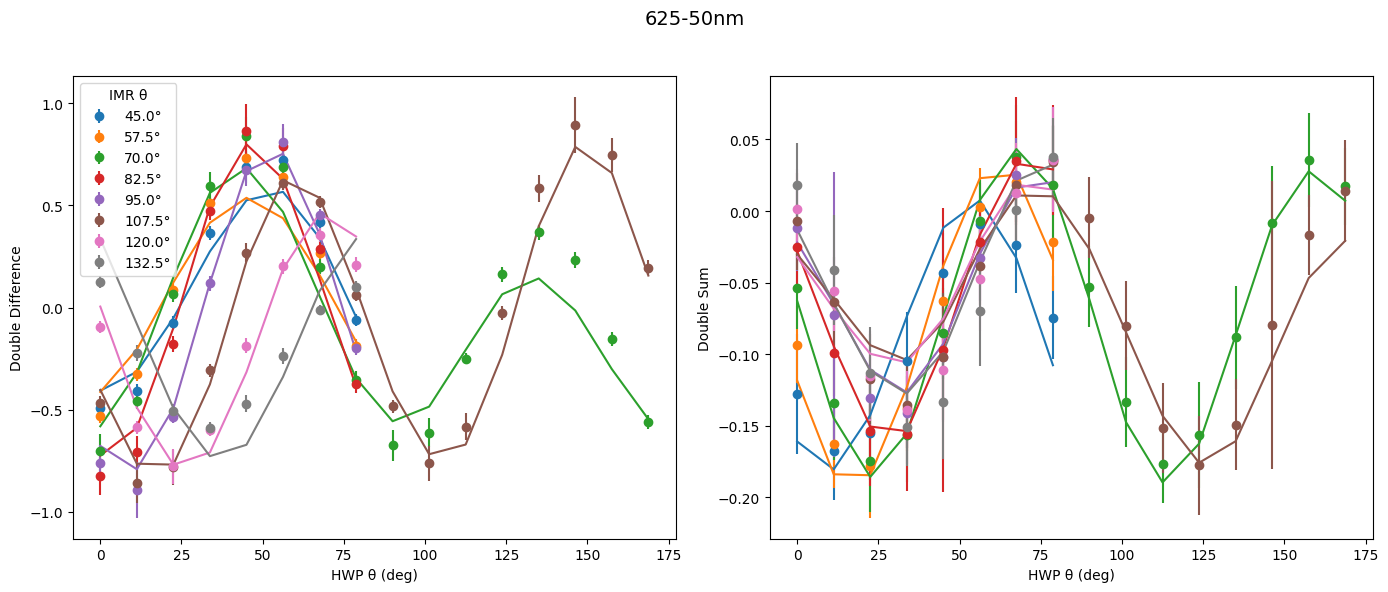

After p0: {'dichroic': {'phi': -0.21867157246930902, 'epsilon': 0.5695328649412498, 'theta': -44.686705214906326}, 'flc': {'phi': 2.9982638208829915, 'delta_theta': 0.6475486773202874}, 'optics': {'phi': -0.7160864340752124, 'epsilon': 0.09759172920841674, 'theta': 22.698313779338378}, 'image_rotator': {'phi': 1.6700880303942356}, 'hwp': {'phi': 2.727368296732495, 'delta_theta': 3.491027163038803}, 'lp': {'theta': 4.9999999996739275}}
Before p0: {'dichroic': {'phi': -0.21867157246930902, 'epsilon': 0.5695328649412498, 'theta': -44.686705214906326}, 'flc': {'phi': 2.9982638208829915, 'delta_theta': 0.6475486773202874}, 'optics': {'phi': -0.7160864340752124, 'epsilon': 0.09759172920841674, 'theta': 22.698313779338378}, 'image_rotator': {'phi': 1.6700880303942356}, 'hwp': {'phi': 2.727368296732495, 'delta_theta': 3.491027163038803}, 'lp': {'theta': 4.9999999996739275}}
Iteration #: 18
logl_value: 329.46558418323355
Best Fit Parameters: [ -0.21867157   0.56953286 -44.68670521   2.99826382 

In [6]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-np.pi, np.pi),  # delta_opts
    (0, 0.1),  # epsilon_opts
    (-90, 90),  # rot_opts
    (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),  # delta_derot
    (delta_HWP - abs(delta_HWP) * 0.1, 0.5 * 2 * np.pi),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

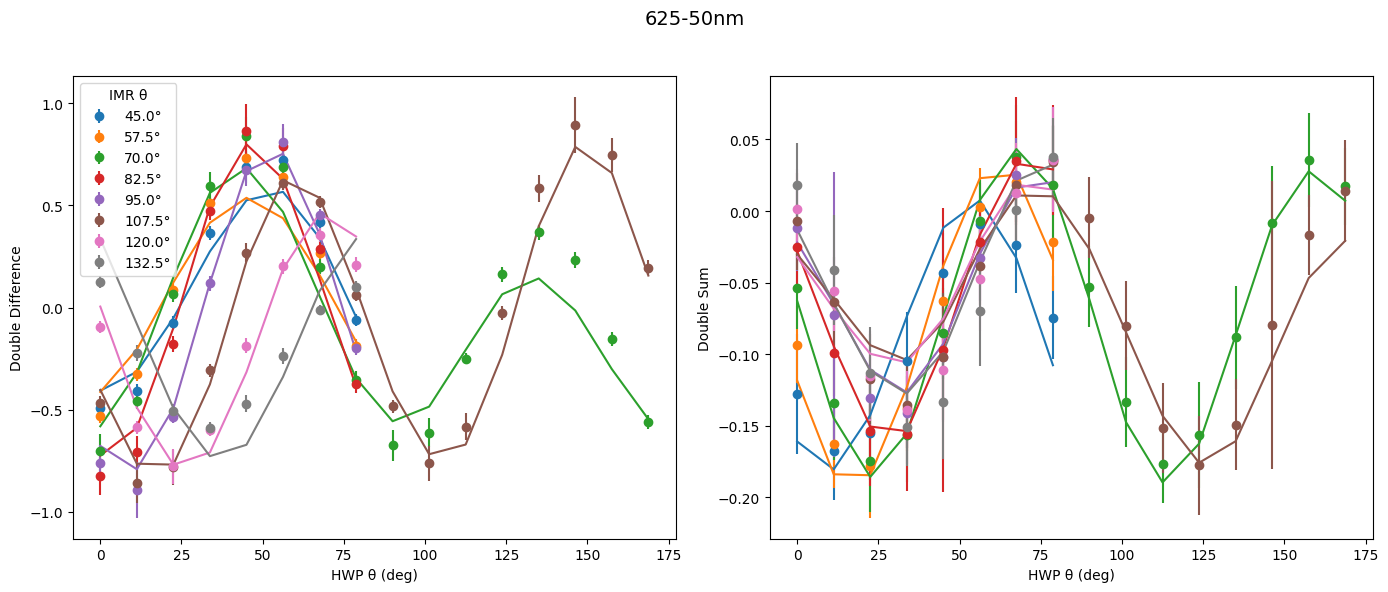

In [7]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
# dichroic_phi = 0 # (waves)
# dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)